In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df = pd.read_csv('data.csv')

In [85]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1753,2057-BOYKM,Female,1,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Bank transfer (automatic),96.60,6827.5,No
594,9244-ZVAPM,Male,0,No,No,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Mailed check,45.60,45.6,No
3151,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,No
1556,3186-BAXNB,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,No,Electronic check,91.70,91.7,Yes
992,4883-KCPZJ,Female,0,Yes,Yes,22,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),25.25,555.4,No


In [86]:
df = df.drop(columns='customerID')

In [87]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [88]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [11]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df.shape

(7043, 20)

<Axes: xlabel='gender'>

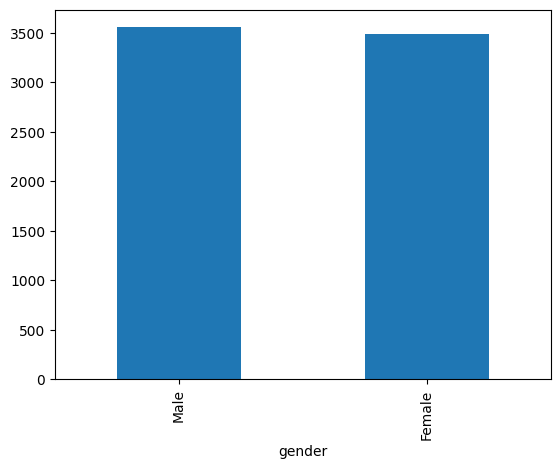

In [14]:
df['gender'].value_counts().plot(kind='bar')

<Axes: xlabel='SeniorCitizen'>

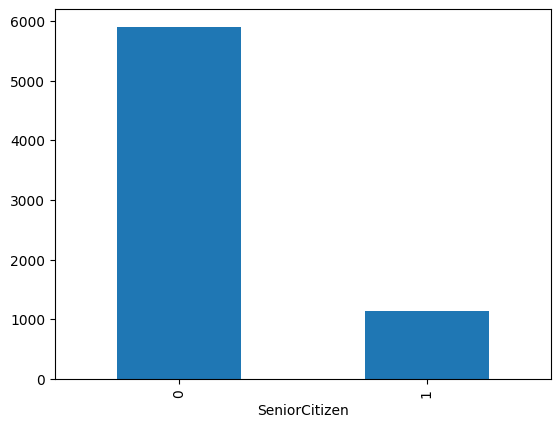

In [15]:
df['SeniorCitizen'].value_counts().plot(kind='bar')

<Axes: xlabel='Partner'>

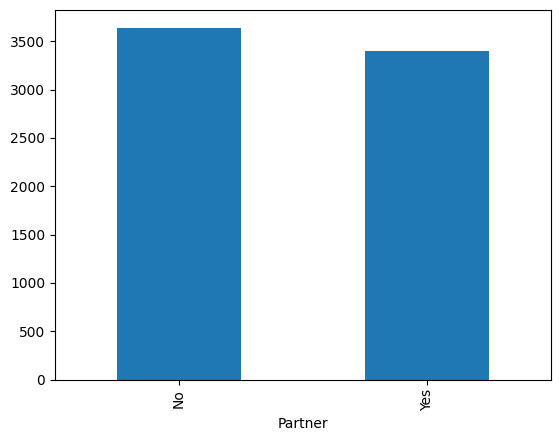

In [16]:
df['Partner'].value_counts().plot(kind='bar')

In [17]:
df[df['tenure'] <= 40].count()

gender              4286
SeniorCitizen       4286
Partner             4286
Dependents          4286
tenure              4286
PhoneService        4286
MultipleLines       4286
InternetService     4286
OnlineSecurity      4286
OnlineBackup        4286
DeviceProtection    4286
TechSupport         4286
StreamingTV         4286
StreamingMovies     4286
Contract            4286
PaperlessBilling    4286
PaymentMethod       4286
MonthlyCharges      4286
TotalCharges        4275
Churn               4286
dtype: int64

<Axes: xlabel='Dependents'>

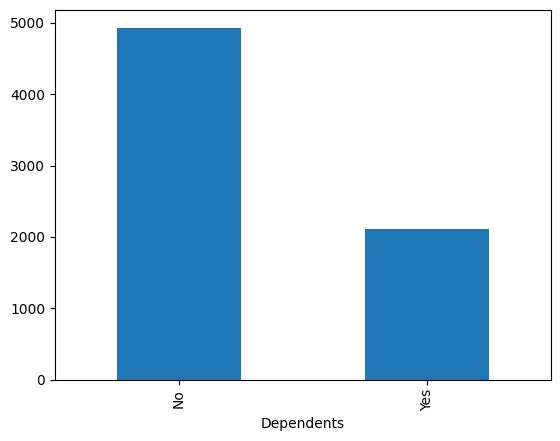

In [18]:
df['Dependents'].value_counts().plot(kind='bar')

<Axes: xlabel='Dependents'>

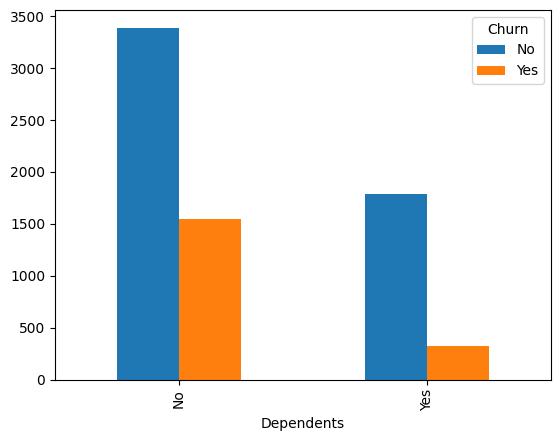

In [19]:
pd.crosstab(df['Dependents'], df['Churn']).plot(kind='bar')


<Axes: xlabel='Dependents', ylabel='count'>

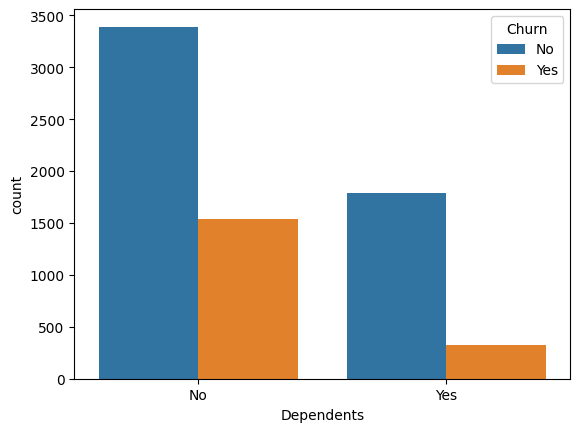

In [20]:
sns.countplot(data=df, x='Dependents', hue='Churn')

<Axes: xlabel='PhoneService'>

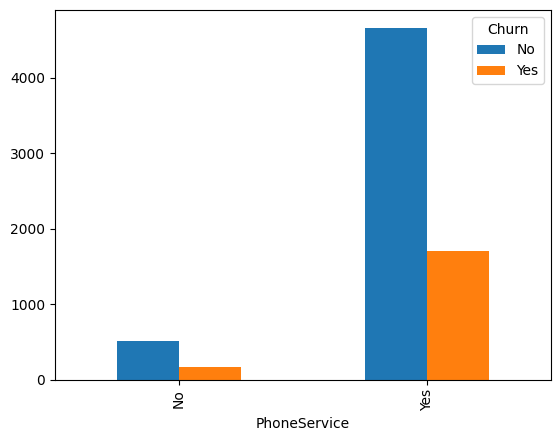

In [21]:
pd.crosstab(df['PhoneService'],df['Churn']).plot(kind='bar')

<Axes: xlabel='MultipleLines', ylabel='count'>

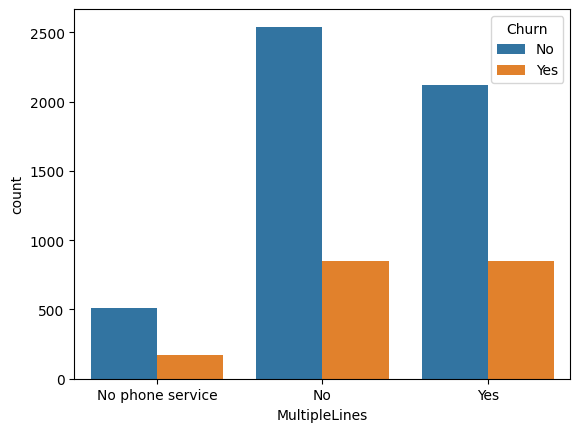

In [22]:
sns.countplot(data=df,x='MultipleLines',hue='Churn')

<Axes: xlabel='InternetService', ylabel='count'>

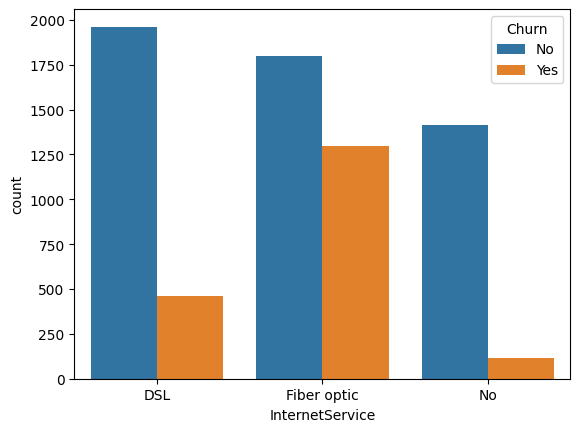

In [23]:
sns.countplot(data=df,x='InternetService', hue='Churn')

<Axes: xlabel='OnlineSecurity', ylabel='count'>

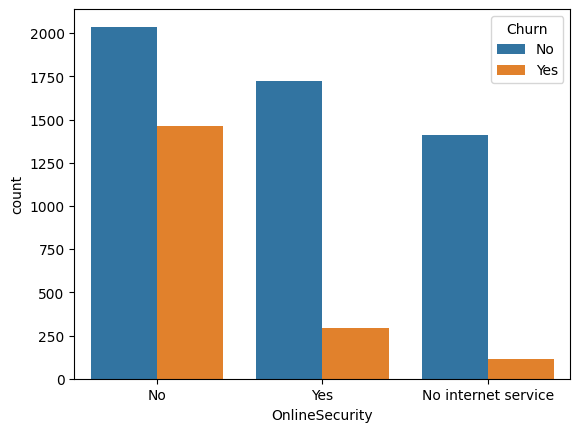

In [24]:
sns.countplot(data=df,x='OnlineSecurity',hue='Churn')

<Axes: xlabel='OnlineBackup'>

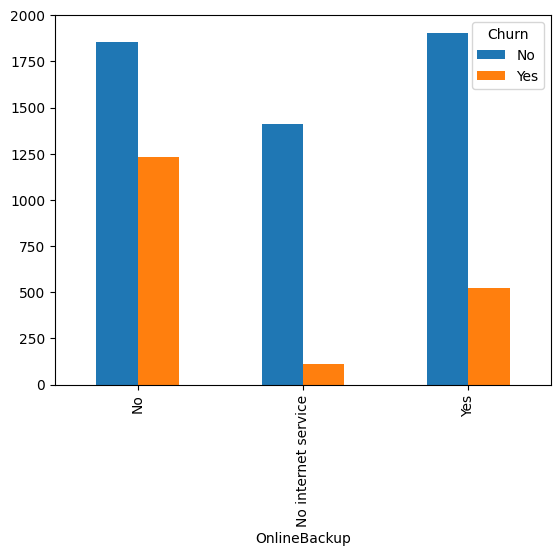

In [25]:
pd.crosstab(df['OnlineBackup'],df['Churn']).plot(kind='bar')

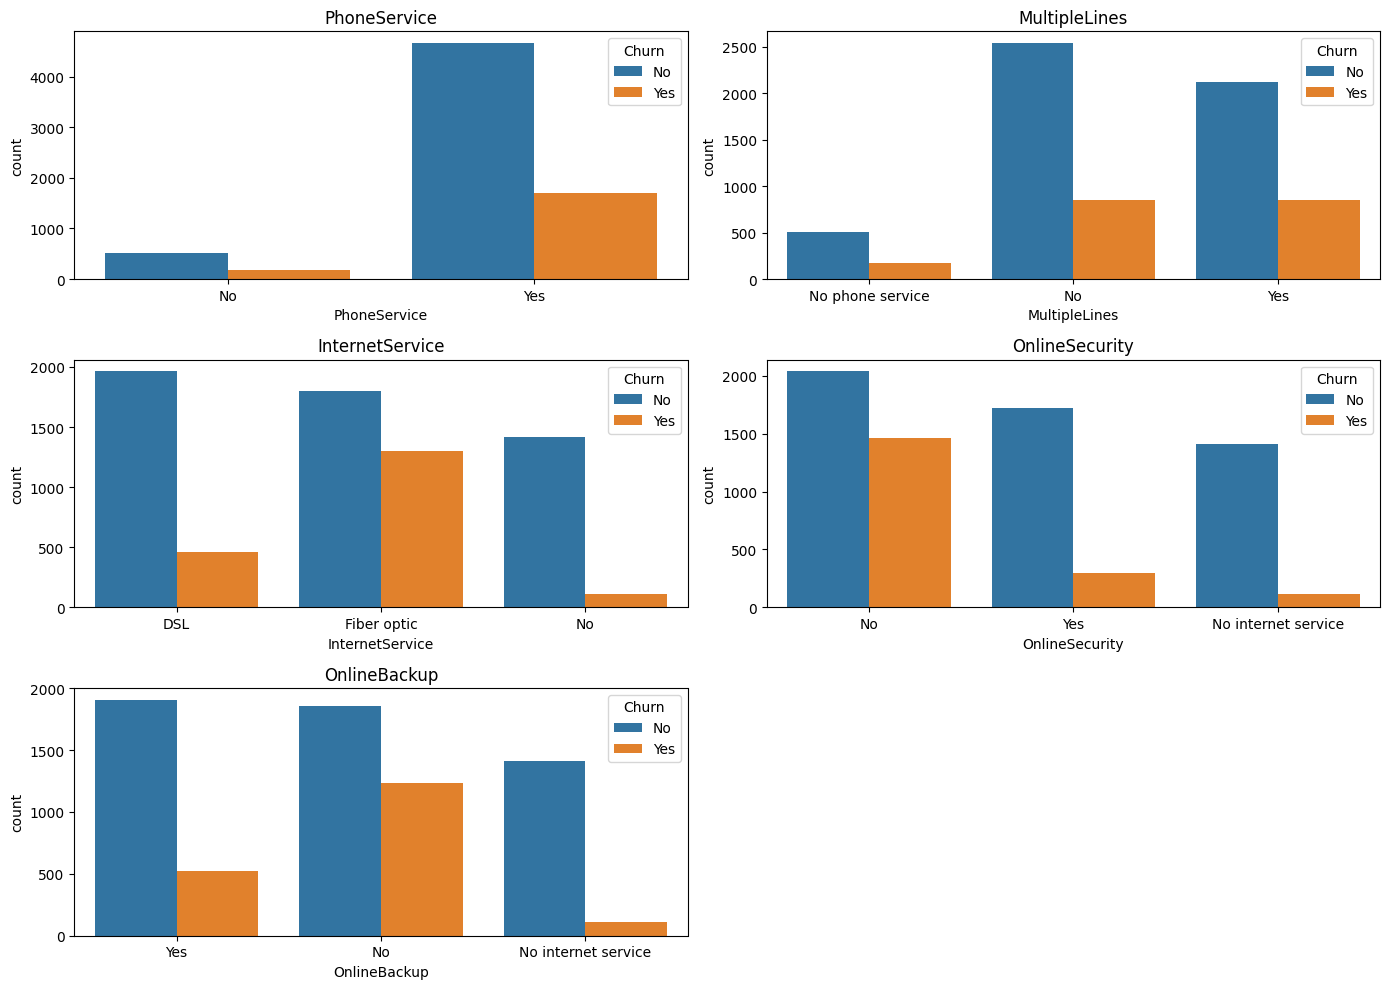

In [26]:
cols = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup'
]

plt.figure(figsize=(14,10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 2, i)
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(col)

plt.tight_layout()
plt.show()

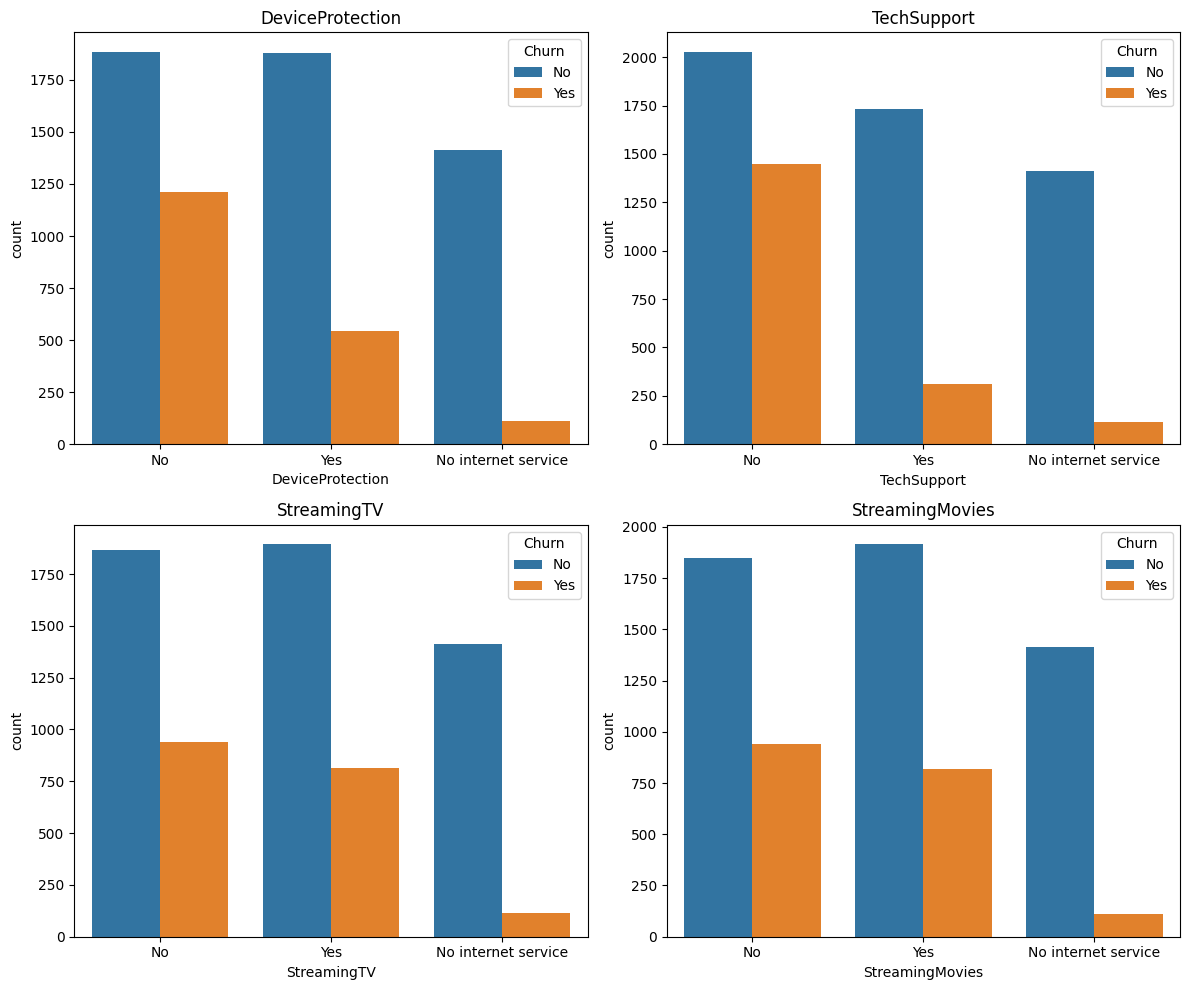

In [27]:
cols = ['DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

plt.figure(figsize=(12,10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(col)

plt.tight_layout()
plt.show()

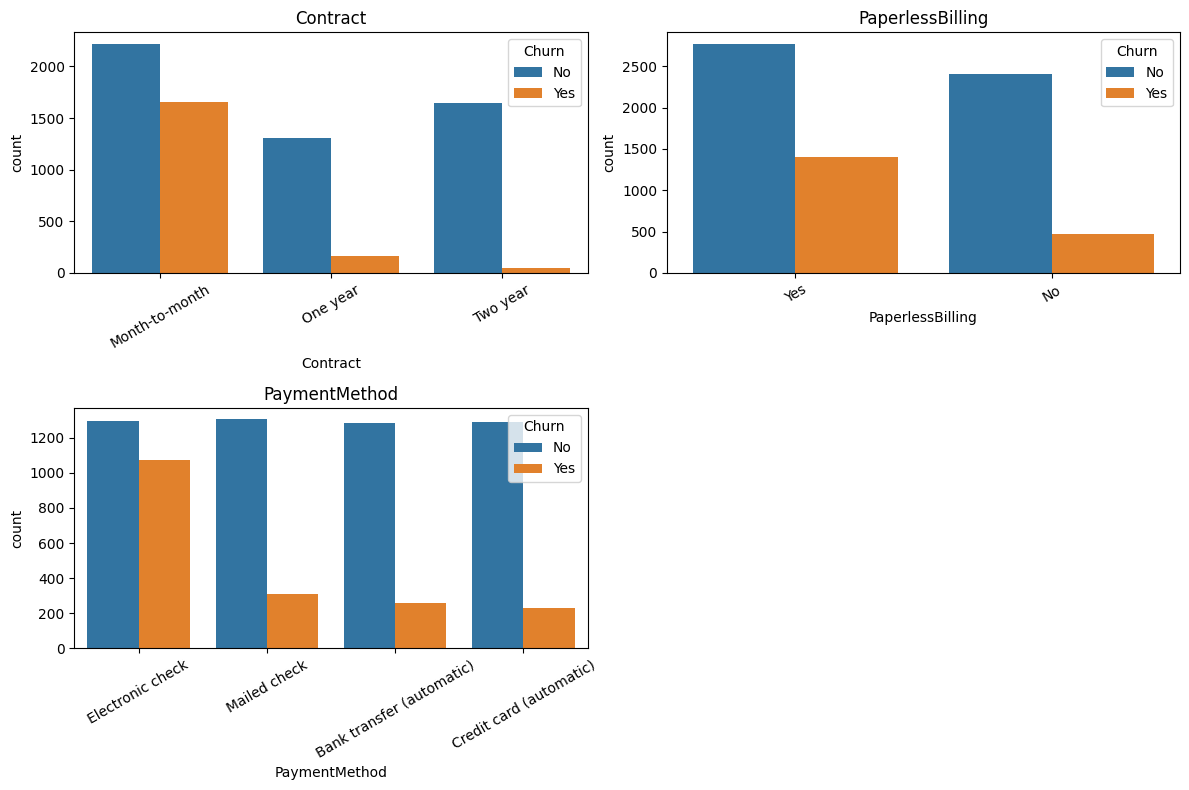

In [28]:
cols = ['Contract', 'PaperlessBilling', 'PaymentMethod']

plt.figure(figsize=(12,8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(col)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [29]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


<Axes: ylabel='Frequency'>

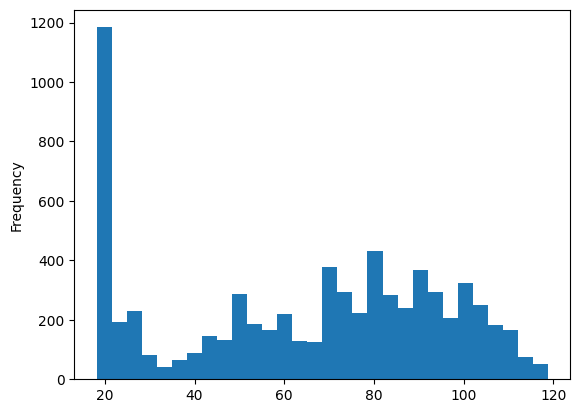

In [30]:
df['MonthlyCharges'].plot(kind='hist', bins=30)

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

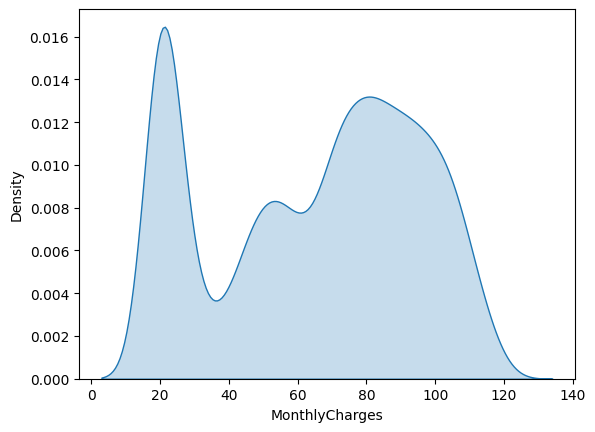

In [32]:
sns.kdeplot(df['MonthlyCharges'], fill=True)

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

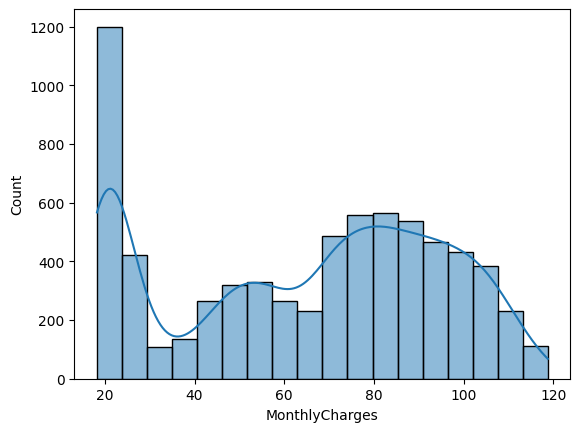

In [33]:
sns.histplot(df['MonthlyCharges'], kde=True)

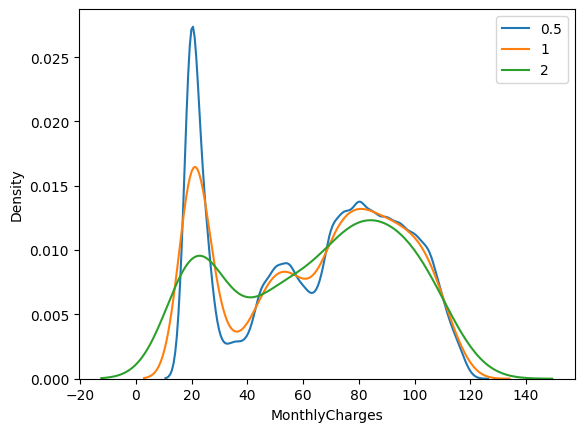

In [34]:
sns.kdeplot(df['MonthlyCharges'], bw_adjust=0.5, label='0.5')
sns.kdeplot(df['MonthlyCharges'], bw_adjust=1, label='1')
sns.kdeplot(df['MonthlyCharges'], bw_adjust=2, label='2')
plt.legend()
plt.show()

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

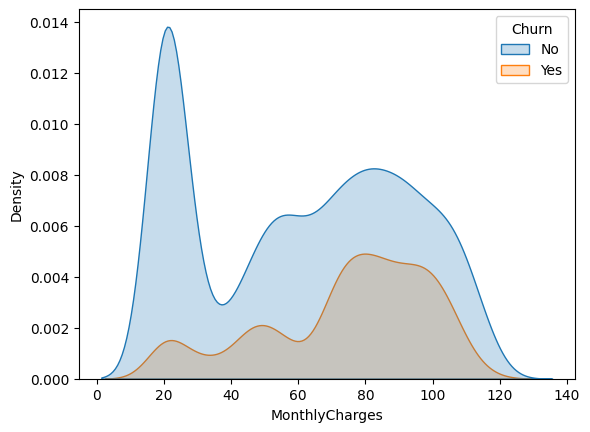

In [35]:
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True)

<Axes: xlabel='TotalCharges', ylabel='Density'>

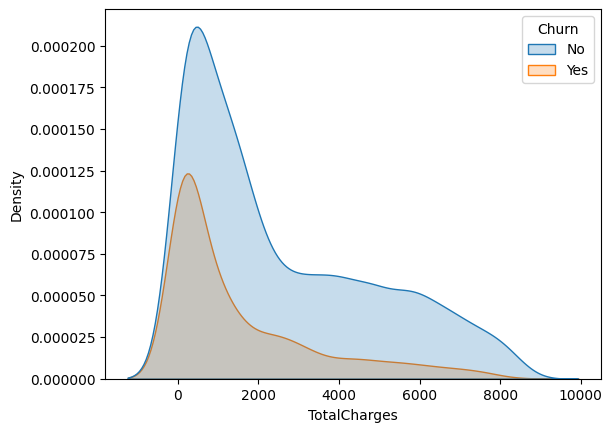

In [36]:
sns.kdeplot(data=df,x='TotalCharges',hue='Churn',fill=True)

In [37]:
df['TotalCharges']

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

<Axes: xlabel='Churn', ylabel='count'>

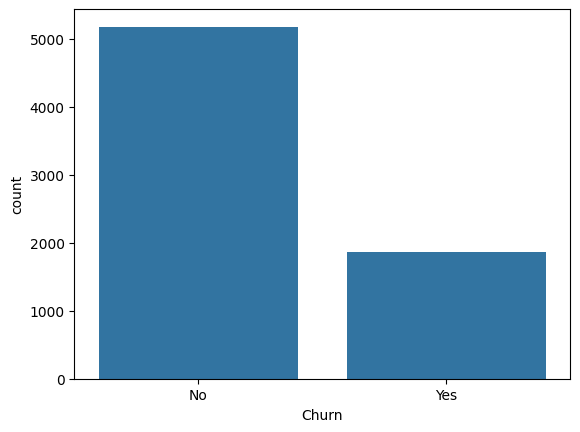

In [38]:
sns.countplot(x='Churn', data=df)

In [79]:
df['Churn']

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: object

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

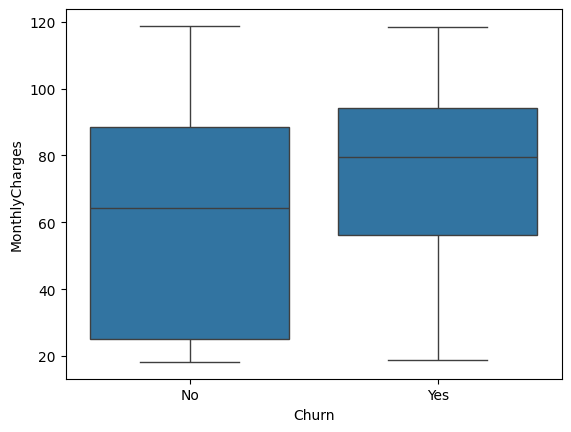

In [40]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

<Axes: xlabel='Churn', ylabel='tenure'>

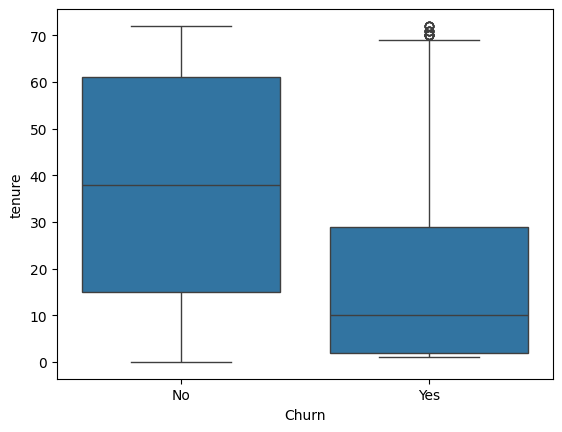

In [41]:
sns.boxplot(x='Churn', y='tenure', data=df)

**MODEL BUILDING**

In [51]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

le = LabelEncoder()
scaler = StandardScaler()

In [90]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
X = df.drop('Churn', axis=1)
y = df['Churn']
X['TotalCharges'] = X['TotalCharges'].fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [91]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = df.columns.drop(num_cols + ['Churn'])
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])
cat_cols

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [94]:
y_train

2142    0
1623    0
6074    1
1362    1
6754    0
       ..
3772    1
5191    0
5226    0
5390    1
860     0
Name: Churn, Length: 5634, dtype: int64

In [95]:
X_train.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [56]:
# !pip install imbalanced-learn

In [97]:
X_test.shape

(1409, 19)

In [96]:
y_train

2142    0
1623    0
6074    1
1362    1
6754    0
       ..
3772    1
5191    0
5226    0
5390    1
860     0
Name: Churn, Length: 5634, dtype: int64

**PIPELINES**

In [98]:
pipe_lr = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
])

pipe_rf = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

pipe_gb = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', GradientBoostingClassifier())
])

pipe_svm = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', SVC(probability=True))
])

pipe_knn = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', KNeighborsClassifier())
])

pipe_xgb = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(eval_metric='logloss', random_state=42))
])

**XGBOOST CLASSIFIER**

In [ ]:
param_grid = {
    'model__n_estimators': [300, 400],
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__subsample': [0.8, 0.9],
    'model__colsample_bytree': [0.8, 0.9]
}

grid = GridSearchCV(
    pipe_xgb,
    param_grid,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_xgb = grid.best_estimator_
best_xgb

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [ ]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

In [ ]:
from sklearn.metrics import roc_auc_score, classification_report

y_prob = best_xgb.predict_proba(X_test)[:,1]
y_pred = best_xgb.predict(X_test)
roc_auc_xgb = roc_auc_score(y_test, y_prob)
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

**LOGISTIC REGRESSION**

In [ ]:
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    pipe_lr,
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
best_lr

In [ ]:
print("Best Parameters:",grid_lr.best_params_)
print("Best CV Score:", grid_lr.best_score_)

In [ ]:
from sklearn.metrics import roc_auc_score, classification_report

y_prob = best_lr.predict_proba(X_test)[:,1]
y_pred = best_lr.predict(X_test)
roc_auc_lr = roc_auc_score(y_test, y_prob)
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

**RANDOM FOREST CLASSIFIER**

In [ ]:
param_dist = {
    'model__n_estimators': [300, 500, 700],
    'model__max_depth': [10, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

grid_rf =  GridSearchCV(
    pipe_rf,
    param_dist,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
best_rf

In [ ]:
print("Best Parameters:",random_rf.best_params_)
print("Best CV Score:", random_rf.best_score_)

In [ ]:
from sklearn.metrics import roc_auc_score, classification_report

y_prob = best_rf.predict_proba(X_test)[:,1]
y_pred = best_rf.predict(X_test)
roc_auc_rf = roc_auc_score(y_test, y_prob)
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

**SUPPORT VECTOR CLASSIFIER**

In [ ]:
param_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['rbf'],
    'model__gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    pipe_svm,
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_
best_svm

In [ ]:
print("Best Parameters:",grid_svm.best_params_)
print("Best CV Score:", grid_svm.best_score_)

In [ ]:
from sklearn.metrics import roc_auc_score, classification_report

y_prob = best_svm.predict_proba(X_test)[:,1]
y_pred = best_svm.predict(X_test)
roc_auc_svm = roc_auc_score(y_test, y_prob)
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

**GRADIENT BOOSTING**

In [ ]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 4]
}

grid_gb = GridSearchCV(
    pipe_gb,
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_
best_gb

In [ ]:
print("Best Parameters:",grid_gb.best_params_)
print("Best CV Score:", grid_gb.best_score_)

In [ ]:
from sklearn.metrics import roc_auc_score, classification_report

y_prob = best_gb.predict_proba(X_test)[:,1]
y_pred = best_gb.predict(X_test)
roc_auc_gb = roc_auc_score(y_test, y_prob)
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

**KNN**

In [ ]:
param_grid = {
    'model__n_neighbors': [3,5,7,9,11],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}
grid_knn = GridSearchCV(
    pipe_knn,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_
best_knn

In [ ]:
print("Best Parameters:",grid_knn.best_params_)
print("Best CV Score:", grid_knn.best_score_)

In [ ]:
from sklearn.metrics import roc_auc_score, classification_report

y_prob = best_knn.predict_proba(X_test)[:,1]
y_pred = best_knn.predict(X_test)
roc_auc_knn = roc_auc_score(y_test, y_prob)
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

**MODEL COMPARISON**

In [ ]:
print("LR:", roc_auc_lr)
print("RF:", roc_auc_rf)
print("XGB:", roc_auc_xgb)
print("SVM:", roc_auc_svm)
print("GB:", roc_auc_gb)
print("KNN:", roc_auc_knn)

In [ ]:
models = {
    "Logistic": best_lr,
    "RandomForest": best_rf,
    "XGBoost": best_xgb,
    "SVM": best_svm,
    "GradientBoost": best_gb,
    "KNearestNeighbour": best_knn
}

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    score = roc_auc_score(y_test, y_prob)
    print(f"{name}: {score}")

In [ ]:
# Logistic Regression
y_prob_lr = best_lr.predict_proba(X_test)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

# Random Forest
y_prob_rf = best_rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# XGBoost
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Svc
y_prob_svm = best_svm.predict_proba(X_test)[:,1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

# GB
y_prob_gb = best_gb.predict_proba(X_test)[:,1]
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)
# Plot
plt.figure(figsize=(7,5))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic (AUC = {auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGB (AUC = {auc_xgb:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVC (AUC = {auc_svm:.3f})")
plt.plot(fpr_gb, tpr_gb, label=f"GB (AUC = {auc_gb:.3f})")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

**VOTING CLASSIFIER**

In [ ]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr', best_lr),
        ('rf', best_rf),
        ('gb', best_gb),
        ('xgb',best_xgb)
    ],
    voting='soft'   # IMPORTANT
)

voting_clf.fit(X_train, y_train)

In [ ]:
y_prob = voting_clf.predict_proba(X_test)[:,1]
y_pred = voting_clf.predict(X_test)
roc_auc_voting = roc_auc_score(y_test, y_prob)
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

**STACKING CLASSIFIER**

In [ ]:
stack_clf = StackingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('rf', best_rf),
        ('gb', best_gb),
        ('lr',best_lr)
    ],
    final_estimator= LogisticRegression(),
    cv=5,
    n_jobs=-1
)
stack_clf.fit(X_train, y_train)

In [ ]:
y_prob = stack_clf.predict_proba(X_test)[:,1]
y_pred = stack_clf.predict(X_test)
roc_auc_stack = roc_auc_score(y_test, y_prob)
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.2, 0.9, 0.05)

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"Threshold: {t:.2f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")

In [ ]:
best_threshold = 0.55
y_pred_final = (y_prob >= best_threshold).astype(int)

In [ ]:
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred_final))

In [ ]:
import matplotlib.pyplot as plt

thresholds = [0.20,0.25,0.30,0.35,0.40,0.45,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85]
precision = [0.407,0.434,0.459,0.486,0.501,0.535,0.559,0.600,0.639,0.666,0.692,0.719,0.753,0.828]
recall = [0.952,0.936,0.920,0.885,0.847,0.815,0.777,0.727,0.660,0.598,0.517,0.432,0.311,0.206]

plt.plot(thresholds, precision, label='Precision')
plt.plot(thresholds, recall, label='Recall')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
cv_score = cross_val_score(stack_clf, X, y, cv=5, scoring='roc_auc')
print("Final CV ROC-AUC:", np.mean(cv_score))

In [ ]:
import joblib
joblib.dump(voting_clf, "churn_model.pkl")

**EXPLAINABILITY**

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(voting_clf, X_test, y_test, n_repeats=10)

imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

In [ ]:
print(imp_df.head(15))